# 01 — Cinematica dello scattering n–p

Il toy model ricostruisce il neutrone incidente a partire dal protone di rinculo di un singolo
scattering elastico n–p. Questo notebook verifica i fatti cinematici su cui si basano tutti i casi
successivi: la relazione energia–angolo, l'isotropia nel centro di massa e il modello di risoluzione
del detector.

**Etichette dei risultati.** (a) fatto consolidato · (b) stima toy con assunzioni esplicite ·
(c) verificato con Monte Carlo · (d) ipotesi da testare.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.stats import kstest, norm

from riptide_toy.constants import SEED, SIGMA_EP, SIGMA_THETA, EN_MIN, EN_MAX

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(SEED)
from riptide_toy import kinematics

## Energia del protone di rinculo

A masse uguali, un protone che rincula ad angolo $\theta_p$ rispetto alla direzione del neutrone
riceve $E_p = E_n\cos^2\theta_p$ **(a)**. Nel laboratorio $\theta_p \le 90^\circ$: il protone
non può rinculare all'indietro.

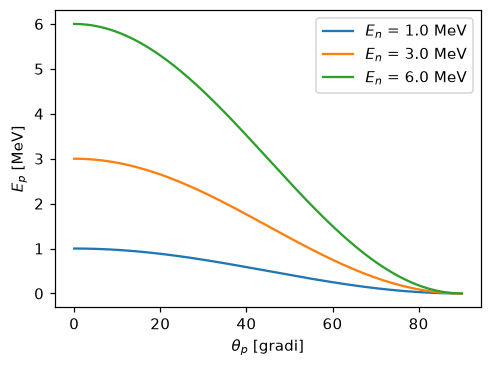

In [2]:
theta = np.linspace(0, np.pi / 2, 200)
fig, ax = plt.subplots(figsize=(5, 3.5))
for En in (1.0, 3.0, 6.0):
    ax.plot(np.degrees(theta), kinematics.proton_energy(En, theta), label=f"$E_n$ = {En} MeV")
ax.set_xlabel(r"$\theta_p$ [gradi]")
ax.set_ylabel(r"$E_p$ [MeV]")
ax.legend()
plt.show()

## Isotropia nel centro di massa

Nel range del toy (0.5–6 MeV) lo scattering n–p è isotropo nel CM: $\cos\theta_{CM}\sim U(-1,1)$
**(b)**. Il protone esce a $\theta_p = (\pi-\theta_{CM})/2$. Ne seguono tre proprietà **(a)**:

* $\cos^2\theta_p \sim U(0,1)$, cioè $E_p \sim U(0, E_n)$;
* $\langle E_p\rangle = E_n/2$ e $\mathrm{Var}(E_p) = E_n^2/12$;
* la densità della traccia per steradiante è $\cos\theta_p/\pi$ sull'emisfero anteriore, e
  quindi in $\theta_p$ vale $p(\theta_p) = \sin 2\theta_p$.

Le verifichiamo con $10^5$ eventi a $E_n = 3$ MeV **(c)**.

<Ep>   = 1.4983   atteso En/2    = 1.5000
Var Ep = 0.7457   atteso En^2/12 = 0.7500
max theta_p = 89.89 gradi
KS cos^2(theta_p) vs U(0,1): p-value = 0.291


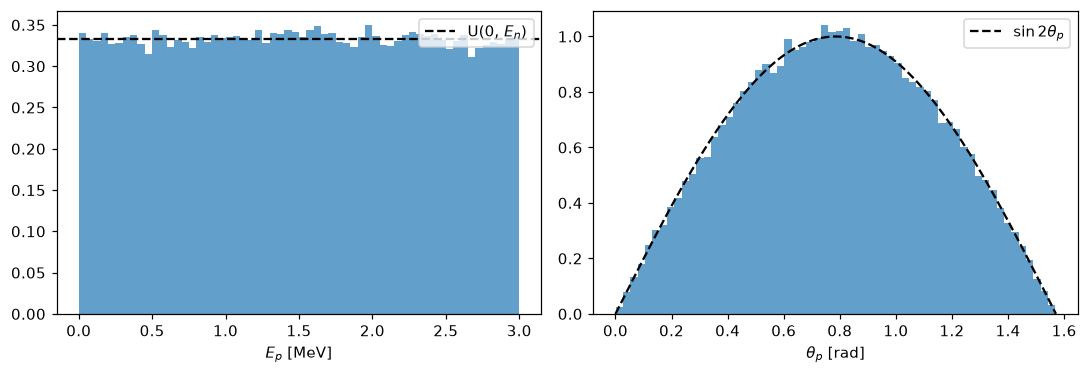

In [3]:
En = 3.0
n = 100_000
omega = np.array([0.0, 0.0, 1.0])
Ep, track = kinematics.sample_recoil_events(rng, np.full(n, En), omega)
theta_p = kinematics.recoil_angle_from_direction(track, omega[None, :])[:, 0]

print(f"<Ep>   = {Ep.mean():.4f}   atteso En/2    = {En / 2:.4f}")
print(f"Var Ep = {Ep.var():.4f}   atteso En^2/12 = {En**2 / 12:.4f}")
print(f"max theta_p = {np.degrees(theta_p.max()):.2f} gradi")
print(f"KS cos^2(theta_p) vs U(0,1): p-value = {kstest(np.cos(theta_p)**2, 'uniform').pvalue:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(Ep, bins=60, density=True, alpha=0.7)
axes[0].axhline(1 / En, color="k", ls="--", label="U(0, $E_n$)")
axes[0].set_xlabel("$E_p$ [MeV]"); axes[0].legend()
axes[1].hist(theta_p, bins=60, density=True, alpha=0.7)
axes[1].plot(theta, np.sin(2 * theta), "k--", label=r"$\sin 2\theta_p$")
axes[1].set_xlabel(r"$\theta_p$ [rad]"); axes[1].legend()
plt.tight_layout(); plt.show()

Nota: un generatore che estrae $\theta_p\sim U(0,\pi/2)$ **non** è fisico. Si concentrerebbe
troppo a grandi angoli e non darebbe $E_p$ uniforme. Nel Caso A questa semplificazione non fa
danni, perché lì la verosimiglianza usa lo stesso prior uniforme su $\theta_p$ e il modello resta
coerente. Nei Casi B e C, invece, la direzione della traccia è un'osservabile, e la sua
distribuzione $\cos\theta_p/\pi$ entra nella verosimiglianza.

## Risoluzione del detector

Il toy usa $\sigma_{E_p} = 0.10$ MeV e $\sigma_\theta = 0.08$ rad (valori dell'Es. 38.1). Per
simulare la risoluzione angolare di una traccia 3D, si sposta la direzione vera nel piano tangente
con una gaussiana isotropa di larghezza $\sigma_\theta$ per componente **(b)**. Ci si aspetta:

* la componente dello spostamento lungo un asse è $N(0,\sigma_\theta)$;
* l'angolo totale di deviazione segue una Rayleigh di parametro $\sigma_\theta$.

rms deviazione = 0.1130 rad, atteso sqrt(2)*sigma = 0.1131


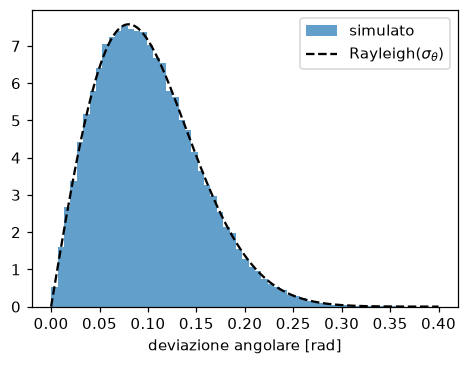

In [4]:
track_hat = kinematics.smear_direction(rng, track, SIGMA_THETA)
delta = np.arccos(np.clip(np.sum(track * track_hat, axis=1), -1, 1))
x = np.linspace(0, 0.4, 200)
print(f"rms deviazione = {np.sqrt(np.mean(delta**2)):.4f} rad, atteso sqrt(2)*sigma = {np.sqrt(2) * SIGMA_THETA:.4f}")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.hist(delta, bins=60, density=True, alpha=0.7, label="simulato")
ax.plot(x, x / SIGMA_THETA**2 * np.exp(-x**2 / (2 * SIGMA_THETA**2)), "k--", label=r"Rayleigh($\sigma_\theta$)")
ax.set_xlabel("deviazione angolare [rad]"); ax.legend()
plt.show()

Un effetto importante della risoluzione angolare: la traccia misurata può avere
$\hat\theta_p > 90^\circ$ rispetto alla direzione vera del neutrone quando il protone esce quasi
perpendicolare. Una verosimiglianza che scartasse come impossibili questi eventi ($-\infty$)
risulterebbe troppo rigida. Il notebook 03 mostra le conseguenze.

In [5]:
theta_obs = kinematics.recoil_angle_from_direction(track_hat, omega[None, :])[:, 0]
print(f"frazione di tracce misurate oltre 90 gradi: {np.mean(theta_obs > np.pi / 2):.4f}")

frazione di tracce misurate oltre 90 gradi: 0.0031
